## Computer Vision - Aufgabe 3: Image Stitching

### Einlesen der Bilder

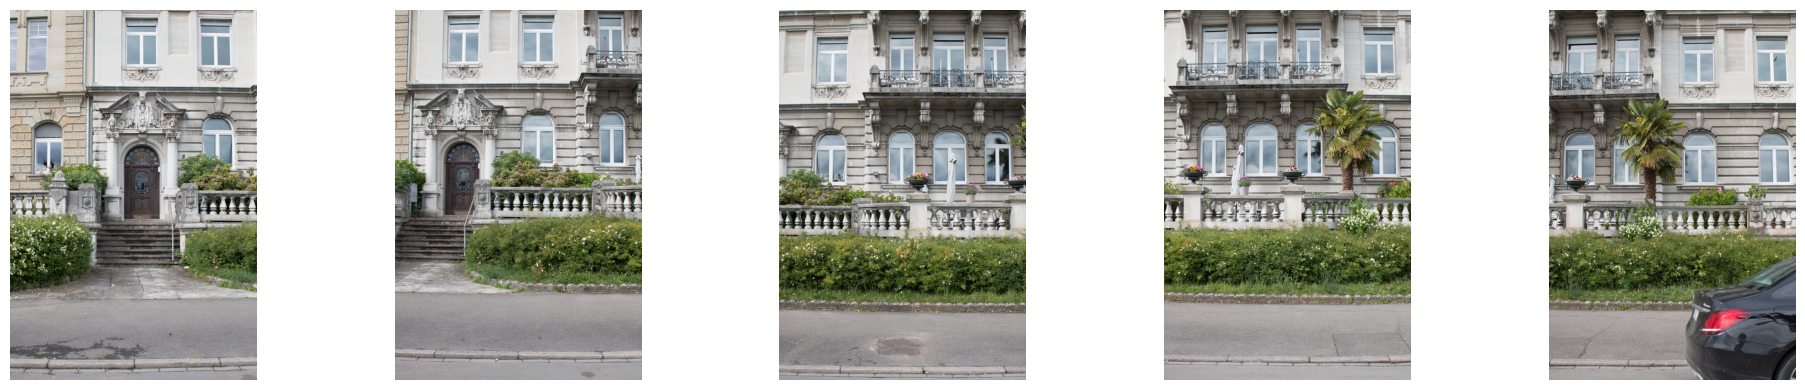

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
from pathlib import Path
import cv2

setname = "Set1"
images = []

for file in Path("Bilder").glob(f"{setname}*"):
    image = plt.imread(file)
    image = image.astype(float)
    image = image / 255
    images.append(image)
image1 = images[0]
image2 = images[1]

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))

# Falls nur ein Bild vorhanden ist:
if len(images) == 1:
    axes = [axes]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
world = {
    # Tür
    "door_bottom":      [0, 1000],
    "door_middle":      [0, 500],
    "door_top":         [0, 0],
    # Pfosten
    "left_post":        [-800, 1000],
    "right_post":       [800, 1000],
    # Fenster 1
    "window1":          [1200, -200],
    # Fenster 2
    "window2":          [2200, -200],
    # Strom Fenster
    "power_window":     [1800, 200],
    # Fenster 3
    "window3":          [3200, -200],
    # Fenster 4
    "window4":          [4200, -200],
    # Deko
    "deco":             [3500, 300],
    # Fenster 5
    "window5":          [5200, -200],
    # Fenster 5 right edge
    "window5_edge":     [5700, 200],
    # Fenster 6
    "window6":          [6500, -200],
    # Fenster 6 bottom-right edge
    "window6_edge":     [7000, 400]
}
scale = 3335 / 7000
PAN_WIDTH = 3335
PAN_HEIGHT = 1000

bi1 = np.array([
    [358.0, 569.9],  # Tür unten
    [358.0, 472.3],  # Tür mitte
    [356.5, 367.7],  # Tür oben
    [511.7, 570.8],  # Rechter Pfosten
    [181.3, 570.8],  # Linker Pfosten
    [560.1, 332.2]   # Fenster 1
])

# bi2 (Pfosten, Fenster 1, Tür oben, Fenster 2, Strom)
bi2 = np.array([
    [261.0, 560.2],  # Rechter Pfosten
    [386.7, 323.1],  # Fenster 1
    [185.5, 360.2],  # Tür oben
    [585.7, 319.4],  # Fenster 2
    [523.2, 386.7]   # Strom Fenster
])

# bi3 (Fenster 2, Strom, Fenster 3, Fenster 4, Deko)
bi3 = np.array([
    [331.0, 369.5],  # Fenster 2
    [261.0, 436.6],  # Strom Fenster
    [460.9, 370.3],  # Fenster 3
    [589.6, 371.0],  # Fenster 4
    [392.7, 389.8]   # Deko
])

# bi4 (Fenster 3, Fenster 4, Deko, Fenster 5, Edge)
bi4 = np.array([
    [262.2, 348.9],  # Fenster 3
    [391.5, 347.2],  # Fenster 4
    [189.1, 369.3],  # Deko
    [585.2, 352.7],  # Fenster 5
    [655.2, 451.6]   # Fenster 5 edge
])

# bi5 (Fenster 5 edge, Fenster 5, Fenster 6, Edge)
bi5 = np.array([
    [470.0, 473.2],  # Fenster 5 edge
    [406.1, 375.2],  # Fenster 5
    [608.6, 374.6],  # Fenster 6
    [655.5, 472.1]   # Fenster 6 edge
])

oi1 = np.array([
    [0.0,    1000.0],
    [0.0,    500.0],
    [0.0,    0.0],
    [381.1,  1000.0], # 800 * 0.47643
    [-381.1, 1000.0], # -800 * 0.47643
    [571.7,  -200.0]  # 1200 * 0.47643
])

# oi2
oi2 = np.array([
    [381.1,  1000.0],
    [571.7,  -200.0],
    [0.0,    0.0],
    [1048.1, -200.0], # 2200 * 0.47643
    [857.6,  200.0]   # 1800 * 0.47643
])

# oi3
oi3 = np.array([
    [1048.1, -200.0],
    [857.6,  200.0],
    [1524.6, -200.0], # 3200 * ...
    [2001.0, -200.0], # 4200 * ...
    [1667.5, 300.0]   # 3500 * ...
])

# oi4
oi4 = np.array([
    [1524.6, -200.0],
    [2001.0, -200.0],
    [1667.5, 300.0],
    [2477.4, -200.0], # 5200 * ...
    [2715.6, 200.0]   # 5700 * ...
])

# oi5
oi5 = np.array([
    [2715.6, 200.0],
    [2477.4, -200.0],
    [3096.8, -200.0], # 6500 * ...
    [3335.0, 400.0]   # 7000 * ... (Matches exactly 667 * 5)
])

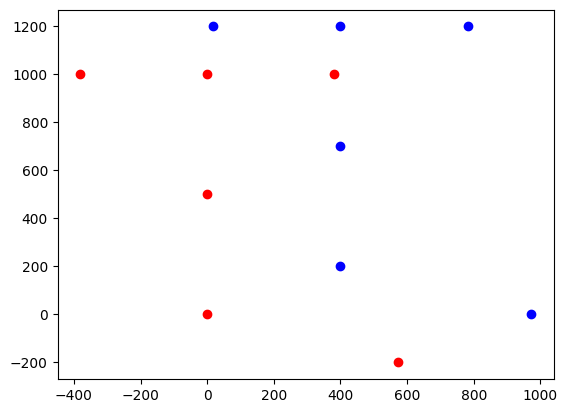

-71789.914 1948.113 -165319.77 2799.15


error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\alloc.cpp:73: error: (-4:Insufficient memory) Failed to allocate 297520442016 bytes in function 'cv::OutOfMemoryError'


In [ ]:
offset_x = 400
offset_y = 200
def translate_oi(oi_array):
    new_oi = oi_array.copy()
    new_oi[:, 0] = (new_oi[:, 0]) + offset_x
    new_oi[:, 1] = (new_oi[:, 1]) + offset_y
    return new_oi
new_oi1 = translate_oi(oi1)
new_oi2 = translate_oi(oi2)
plt.scatter(oi1[:,0], oi1[:,1], c='red')
plt.scatter(new_oi1[:,0], new_oi1[:,1], c='blue')
plt.show()

def compute_rectification(bi, oi):
    A = []
    for i in range(len(oi)):
        x, y = bi[i]
        u, v = oi[i]
        A.append([x, y, 1, 0, 0, 0, -(u*x), -(u*y)])
        A.append([0, 0, 0, x, y, 1, -(v*x), -(v*y)])
    A = np.array(A)

    x = oi.flatten()
    h = np.linalg.pinv(A) @ x
    H = np.array([
    [h[0], h[1], h[2]],
    [h[3], h[4], h[5]],
    [h[6], h[7], 1]
    ])
    return H

def compute_weights(height, width):
    weights = np.zeros((height, width))
    for i in range(height):
        for j in range(width):
            w1 = 1 - (2/width) * abs(j - width/2)
            w2 = 1 - (2/height) * abs(i - height/2)
            weights[i, j] = w1 * w2
    return weights

def image_rectification(image, H, out_h, out_w):

    H_inv = np.linalg.inv(H)

    rectified_image = np.zeros((out_h, out_w, 3),
                               dtype=image.dtype)

    for y_ref in range(out_h):
        for x_ref in range(out_w):

            # Zielpunkt im Panorama
            p_ref = np.array([x_ref, y_ref, 1])

            # Rücktransformation ins Bild
            p_img = H_inv @ p_ref

            # Homogene Koordinaten normieren
            p_img /= p_img[2]

            x = p_img[0]
            y = p_img[1]

            x_n = int(np.round(x))
            y_n = int(np.round(y))

            if (0 <= x_n < image.shape[1] and
                0 <= y_n < image.shape[0]):

                rectified_image[y_ref, x_ref] = image[y_n, x_n]

    return rectified_image


def test_homography(H, img_pts, world_pts):
    img_pts = np.array(img_pts, dtype=np.float32)
    world_pts = np.array(world_pts, dtype=np.float32)

    img_h = np.hstack([img_pts, np.ones((len(img_pts),1))])

    projected = (H @ img_h.T).T
    projected /= projected[:,2:3]

    print("\nProjection check:")
    print("Predicted vs Ground Truth:\n")

    for i in range(len(img_pts)):
        print(f"pred: {projected[i,:2]}  |  true: {world_pts[i]}")


#H1 = compute_rectification(bi1, new_oi1)
#H2 = compute_rectification(bi2, new_oi2)
#test_homography(H1, bi1, new_oi1)
#test_homography(H2, bi2, new_oi2)
#H1 = compute_rectification(bi1, oi1)
#H2 = compute_rectification(bi2, oi2)
#rectified_image1 = image_rectification(image1, H1, PAN_HEIGHT, PAN_WIDTH)
#rectified_image2 = image_rectification(image2, H2, PAN_HEIGHT, PAN_WIDTH)

H1, _ = cv2.findHomography(bi1, oi1)
H2, _ = cv2.findHomography(bi2, oi2)

# Hier bounding definieren
h, w = image1.shape[:2]

corners = np.array([
    [0, 0],
    [w, 0],
    [w, h],
    [0, h]
], dtype=np.float32)

corners_h = cv2.perspectiveTransform(
    corners.reshape(-1,1,2),
    H1
)

xs = corners_h[:,0,0]
ys = corners_h[:,0,1]

xmin = np.min(xs)
xmax = np.max(xs)

ymin = np.min(ys)
ymax = np.max(ys)

print(xmin, xmax, ymin, ymax)

tx = -xmin
ty = -ymin

T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

H1_shifted = T @ H1

pan_width  = int(xmax - xmin)
pan_height = int(ymax - ymin)

rectified_image1 = cv2.warpPerspective(
    image1,
    H1_shifted,
    (pan_width, pan_height)
)
rectified_image2 = cv2.warpPerspective(
    image2,
    H2,
    (PAN_WIDTH, PAN_HEIGHT)
)



plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rectified_image1)
plt.title("Rektifiziertes Bild 1")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rectified_image2)
plt.title("Rektifiziertes Bild 2")
plt.axis('off')



Text(0.5, 1.0, 'Blended Image')

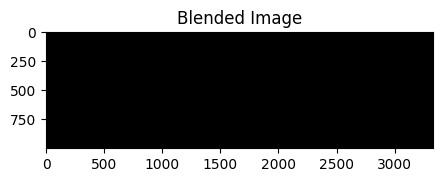

In [7]:
def blend_images(img1, img2, mode="average"):

    h, w = img1.shape[:2]

    weights1 = compute_weights(h, w)
    weights2 = compute_weights(h, w)

    output = np.zeros_like(img1, dtype=np.float32)

    for y in range(h):
        for x in range(w):

            p1 = img1[y, x].astype(np.float32)
            p2 = img2[y, x].astype(np.float32)

            w1 = weights1[y, x]
            w2 = weights2[y, x]

            valid1 = np.any(p1 > 0)
            valid2 = np.any(p2 > 0)

            if valid1 and not valid2:
                output[y, x] = p1

            elif valid2 and not valid1:
                output[y, x] = p2

            elif valid1 and valid2:

                if mode == "max":
                    if w1 > w2:
                        output[y, x] = p1
                    else:
                        output[y, x] = p2

                elif mode == "average":
                    output[y, x] = (w1*p1 + w2*p2) / (w1 + w2)

    return output.astype(np.uint8)
blended_image = blend_images(rectified_image1, rectified_image2, mode="max")
plt.figure(figsize=(5, 5))
plt.imshow(blended_image)
plt.title("Blended Image")

In [5]:
'''Bild 1:
1959, 3117 # Mitte Tür unten
1959, 2583 # Mitte Tür
1951, 2011 # Mitte Tür oben ---- Überlappung
2800, 3122 # Rechter Pfosten links ---- Überlappung
992, 3122 # Linker Pfosten links
3065, 1817 # Mitte Fenster ---- Überlappung

Bild 2:
1428, 3064 # Rechter Pfosten links ---- Überlappung
2116, 1767 # Mitte Fenster ---- Überlappung
1015, 1970 # Mitte Tür oben ---- Überlappung
3205, 1747 # Fenster 2 mitte ---- Überlappung 2
2863, 2115 # Strom Fenster ---- Überlappung 2

Bild 3:
1811, 2021 # Fenster 2 mitte ---- Überlappung 2
1428, 2388 # Strom Fenster ---- Überlappung 2
2522, 2025 # Fenster 3 Mitte ---- Überlappung 3
3226, 2029 # Fenster 4 Mitte ---- Überlappung 3
2149, 2132 # Mitte Deko ---- Überlappung 3

Bild 4:
1435, 1908 # Fenster 3 Mitte ---- Überlappung 3
2142, 1899 # Fenster 4 Mitte ---- Überlappung 3
1035, 2020 # Mitte Deko ---- Überlappung 3
3202, 1929 # Fenster 5 Mitte ---- Überlappung 4
3585, 2470 # Kante rechts Fenster 5 ---- Überlappung 4

Bild 5:
2572, 2588 # Kante rechts Fenster 5 ---- Überlappung 4
2222, 2052 # Fenster 5 Mitte ---- Überlappung 4
3330, 2049 # Fenster 6 Mitte
3587, 2582 # Fenster 6 rahmenkante unten rechts'''

'Bild 1:\n1959, 3117 # Mitte Tür unten\n1959, 2583 # Mitte Tür\n1951, 2011 # Mitte Tür oben ---- Überlappung\n2800, 3122 # Rechter Pfosten links ---- Überlappung\n992, 3122 # Linker Pfosten links\n3065, 1817 # Mitte Fenster ---- Überlappung\n\nBild 2:\n1428, 3064 # Rechter Pfosten links ---- Überlappung\n2116, 1767 # Mitte Fenster ---- Überlappung\n1015, 1970 # Mitte Tür oben ---- Überlappung\n3205, 1747 # Fenster 2 mitte ---- Überlappung 2\n2863, 2115 # Strom Fenster ---- Überlappung 2\n\nBild 3:\n1811, 2021 # Fenster 2 mitte ---- Überlappung 2\n1428, 2388 # Strom Fenster ---- Überlappung 2\n2522, 2025 # Fenster 3 Mitte ---- Überlappung 3\n3226, 2029 # Fenster 4 Mitte ---- Überlappung 3\n2149, 2132 # Mitte Deko ---- Überlappung 3\n\nBild 4:\n1435, 1908 # Fenster 3 Mitte ---- Überlappung 3\n2142, 1899 # Fenster 4 Mitte ---- Überlappung 3\n1035, 2020 # Mitte Deko ---- Überlappung 3\n3202, 1929 # Fenster 5 Mitte ---- Überlappung 4\n3585, 2470 # Kante rechts Fenster 5 ---- Überlappung 4\n